In [3]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────────
!pip -q install gdown tqdm yacs Cython scipy prefetch_generator imageio scikit-learn loguru
!pip -q uninstall -y opencv-python-headless opencv-contrib-python-headless
!pip -q install opencv-contrib-python-headless
!pip -q install pycocotools

In [4]:
# ── Cell 2: Mount Drive, clone YOLOPX, download weights ──────────────────────
from google.colab import drive
drive.mount("/content/drive")

!rm -rf /content/YOLOPX
!git clone -q https://github.com/jiaoZ7688/YOLOPX.git /content/YOLOPX
%cd /content/YOLOPX
!pip -q install -r requirements.txt
!mkdir -p weights
!gdown --id 1dlwaElu0dQQdoEeJkuP2LKGx1TSCjE-z -O weights/epoch-195.pth
print("Repo + weights ready:", __import__("os").path.exists("weights/epoch-195.pth"))


Mounted at /content/drive
/content/YOLOPX
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 15.5 MB/s eta 0:00:00:00:0100:01
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1dlwaElu0dQQdoEeJkuP2LKGx1TSCjE-z
From (redirected): https://drive.google.com/uc?id=1dlwaElu0dQQdoEeJkuP2LKGx1TSCjE-z&confirm=t&uuid=ba238a2f-1d83-41f4-ad88-7e6529d8dde3
To: /content/YOLOPX/weights/epoch-195.pth
100% 397M/397M [00:02<00:00, 144MB/s]  
Repo + weights ready: True


In [5]:
# ── Cell 3: Paths & experiment config ─────────────────────────────────────────
import os

DATA_DIR   = "/content/drive/MyDrive/India's New York City - Mumbai 4K - Driving Downtown_30fps"
ANN_FILE   = os.path.join(DATA_DIR, "default_instances.json")
IMG_DIR    = os.path.join(DATA_DIR, "images")

SKIP_RATES  = [1,3,5,10]
MODES       = ["copy_forward", "sparse_flow"]
DILATION_K  = 1
IMG_SIZE    = 640


In [6]:
# ── Cell 4: Imports + all helper functions ────────────────────────────────────
import sys, time
import numpy as np
import cv2
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from pycocotools.coco import COCO

sys.path.append("/content/YOLOPX")
from lib.config import cfg
from lib.models import get_net
from lib.dataset import LoadImages

import io

class SilentLoadImages:
    """Wraps LoadImages and suppresses its per-frame stdout print."""
    def __init__(self, *args, **kwargs):
        self._loader  = LoadImages(*args, **kwargs)
        self._iter    = None
        self._devnull = open(os.devnull, "w")

    def __len__(self):
        return len(self._loader)

    def __iter__(self):
        self._iter = iter(self._loader)   # ← this call sets self._loader.count = 0
        return self                        #   and all other internal state

    def __next__(self):
        old_stdout = sys.stdout
        sys.stdout = self._devnull
        try:
            return next(self._iter)        # ← delegates to the initialised iterator
        finally:
            sys.stdout = old_stdout        # always restore, even on StopIteration

    def __del__(self):
        self._devnull.close()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Image normalisation transform
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225])
transform  = transforms.Compose([transforms.ToTensor(), normalize])


# ── 1. Lane mask cleaner ─────────────────────────────────────────────────────
def clean_lane_mask(mask: np.ndarray) -> np.ndarray:
    mask = mask.astype(np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  np.ones((3, 3), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = np.zeros_like(mask)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= 30:
            out[labels == i] = 255
    return out


# ── 2. Run model on a single tensor (GPU, with synchronize) ──────────────────
def run_model(img_tensor, img_det_shape, shapes):
    """Returns lane mask (H x W, uint8, 0 or 255). Caller must hold torch.no_grad()."""

    # ── FIX: ensure spatial dims are divisible by 32 ──────────────────
    _, _, h_in, w_in = img_tensor.shape
    new_h = (h_in // 32) * 32
    new_w = (w_in // 32) * 32
    if new_h != h_in or new_w != w_in:
        img_tensor = F.interpolate(
            img_tensor, size=(new_h, new_w),
            mode='bilinear', align_corners=False
        )
    # ──────────────────────────────────────────────────────────────────

    _, da, ll = model(img_tensor)
    _, _, H, W = img_tensor.shape          # now H and W are already aligned
    h, w = img_det_shape[:2]
    pw, ph   = int(shapes[1][1][0]), int(shapes[1][1][1])
    pl, pr   = pw // 2, pw - pw // 2
    pt, pb   = ph // 2, ph - ph // 2
    ll       = ll[:, :, pt:H-pb, pl:W-pr]
    ll       = F.interpolate(ll, (h, w), mode="bilinear", align_corners=False)
    _, ll    = torch.max(ll, 1)
    mask     = ll.int().squeeze().cpu().numpy().astype(np.uint8) * 255
    return clean_lane_mask(mask)


# ── 3. Sparse optical flow propagation (LK + affine warp) ───────────────────
def propagate_sparse(prev_gray: np.ndarray,
                     curr_gray: np.ndarray,
                     prev_mask: np.ndarray) -> np.ndarray:
    """
    Track ~200 corner points with Lucas-Kanade PyrLK,
    estimate a partial affine transform, warp the mask.
    Runs in ~5-12 ms on CPU at 720p — far cheaper than Farneback.
    Falls back to copy-forward if tracking fails.
    """
    pts = cv2.goodFeaturesToTrack(prev_gray, maxCorners=200,
                                   qualityLevel=0.01, minDistance=10,
                                   blockSize=5)
    if pts is None or len(pts) < 6:
        return prev_mask.copy()

    curr_pts, status, _ = cv2.calcOpticalFlowPyrLK(
        prev_gray, curr_gray, pts, None,
        winSize=(15, 15), maxLevel=2,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

    good_p = pts[status.ravel() == 1]
    good_c = curr_pts[status.ravel() == 1]
    if len(good_p) < 6:
        return prev_mask.copy()

    M, _ = cv2.estimateAffinePartial2D(good_p, good_c,
                                        method=cv2.RANSAC,
                                        ransacReprojThreshold=3.0)
    if M is None:
        return prev_mask.copy()

    h, w = prev_mask.shape
    return cv2.warpAffine(prev_mask, M, (w, h),
                           flags=cv2.INTER_NEAREST,
                           borderMode=cv2.BORDER_CONSTANT, borderValue=0)


# ── 4. Dilation + metrics ────────────────────────────────────────────────────
def dilate_mask(mask: np.ndarray, k: int = 1) -> np.ndarray:
    kern = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    return cv2.dilate(mask, kern, iterations=1)


def compute_metrics(gt: np.ndarray, pred: np.ndarray) -> dict:
    gt   = (gt   > 0).astype(np.uint8)
    pred = (pred > 0).astype(np.uint8)
    tp   = np.logical_and(gt == 1, pred == 1).sum()
    tn   = np.logical_and(gt == 0, pred == 0).sum()
    fp   = np.logical_and(gt == 0, pred == 1).sum()
    fn   = np.logical_and(gt == 1, pred == 0).sum()
    eps  = 1e-7
    return dict(
        iou_lane = tp / (tp + fp + fn + eps),
        iou_bg   = tn / (tn + fp + fn + eps),
        miou     = (tp / (tp+fp+fn+eps) + tn / (tn+fp+fn+eps)) / 2,
        dice     = (2*tp) / (2*tp + fp + fn + eps),
        recall   = tp / (tp + fn + eps),
    )

print("All helpers defined.")


Device: cuda:0
All helpers defined.


In [7]:
# Load model
model = get_net(cfg)
ckpt  = torch.load('/content/YOLOPX/weights/epoch-195.pth', map_location=device)
model.load_state_dict(ckpt['state_dict'], strict=True)
model = model.to(device).eval()

# ── FIX: only use half-precision if all layers support it ──────────────
USE_HALF = device.type == 'cuda'

if USE_HALF:
    try:
        model = model.half()
        # Test if it actually works
        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE).half().to(device)
            _ = model(dummy)
        print("✅ Running in float16 (half precision)")
    except RuntimeError:
        # Some layers can't handle half — fall back to float32
        model = model.float()
        USE_HALF = False
        print("⚠️  Half precision failed, falling back to float32")
else:
    print("ℹ️  Running on CPU in float32")

# Final warm-up pass
with torch.no_grad():
    dtype = torch.float16 if USE_HALF else torch.float32
    dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, dtype=dtype).to(device)
    _ = model(dummy)

if device.type == 'cuda':
    torch.cuda.synchronize()

print("Model loaded and warmed up.")

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


✅ Running in float16 (half precision)
Model loaded and warmed up.


In [8]:
# ── Cell 6: Pre-compute all GT masks (run once, reuse in sweep) ───────────────
coco         = COCO(ANN_FILE)
cats         = coco.loadCats(coco.getCatIds())
lane_cat_ids = [c["id"] for c in cats if "lane" in c["name"].lower()]
use_cat_ids  = lane_cat_ids if lane_cat_ids else coco.getCatIds()

img_ids_ordered = sorted(coco.getImgIds())
frame_meta      = []    # ordered list of {base, img_path}
gt_cache        = {}    # base_name -> gt mask (uint8, values 0/1)

print(f"Pre-computing GT masks for {len(img_ids_ordered)} frames...")
for img_id in tqdm(img_ids_ordered, leave=False):
    info    = coco.loadImgs(img_id)[0]
    base    = os.path.basename(info["file_name"])
    h, w    = info["height"], info["width"]
    mask    = np.zeros((h, w), dtype=np.uint8)
    ann_ids = coco.getAnnIds(imgIds=img_id, catIds=use_cat_ids)
    for ann in coco.loadAnns(ann_ids):
        mask = np.maximum(mask, coco.annToMask(ann).astype(np.uint8))
    gt_cache[base] = (mask * 255).astype(np.uint8)   # values 0 or 255  ← FIXED                            # values 0 or 1
    frame_meta.append({"base": base,
                       "img_path": os.path.join(IMG_DIR, base)})

print(f"Cached {len(gt_cache)} GT masks. Ready for sweep.")


loading annotations into memory...
Done (t=48.46s)
creating index...
index created!
Pre-computing GT masks for 8639 frames...


Cached 8639 GT masks. Ready for sweep.


In [9]:
# Check what's actually in the annotation file
print("Total images in COCO:", len(coco.getImgIds()))
print("Total annotations:", len(coco.getAnnIds()))
print("All categories:", coco.loadCats(coco.getCatIds()))
print("lane_cat_ids found:", lane_cat_ids)
print("use_cat_ids:", use_cat_ids)

# Check a specific image
img_id = img_ids_ordered[0]
info = coco.loadImgs(img_id)[0]
print("\nFirst image:", info["file_name"])
ann_ids = coco.getAnnIds(imgIds=img_id)   # NO catId filter
print("Annotations (no filter):", len(ann_ids))
ann_ids_filtered = coco.getAnnIds(imgIds=img_id, catIds=use_cat_ids)
print("Annotations (with catId filter):", len(ann_ids_filtered))

# Show first annotation raw
if ann_ids:
    ann = coco.loadAnns(ann_ids)[0]
    print("\nFirst annotation:", ann)
    m = coco.annToMask(ann)
    print("Mask shape:", m.shape, "nonzero:", np.count_nonzero(m))

Total images in COCO: 8639
Total annotations: 29204
All categories: [{'id': 1, 'name': 'lane', 'supercategory': 'road'}]
lane_cat_ids found: [1]
use_cat_ids: [1]

First image: images/frame_00001.jpg
Annotations (no filter): 0
Annotations (with catId filter): 0


In [10]:
#cell 7  ── Copy images from Drive to local /content/ (run once per session) ──────────
import os
import time
import shutil
import zipfile
from tqdm.notebook import tqdm

LOCAL_IMG_DIR = "/content/frames"
ZIP_PATH_ON_DRIVE = os.path.join(DATA_DIR, "images.zip")
LOCAL_ZIP_PATH = "/content/images.zip"

def copy_file_with_progress(src, dst, desc="Copying"):
    total_size = os.path.getsize(src)
    chunk_size = 4 * 1024 * 1024  # 4MB chunks
    with open(src, 'rb') as fsrc, open(dst, 'wb') as fdst:
        with tqdm(total=total_size, unit='B', unit_scale=True, desc=desc) as pbar:
            while True:
                buf = fsrc.read(chunk_size)
                if not buf:
                    break
                fdst.write(buf)
                pbar.update(len(buf))

def unzip_with_progress(zip_path, extract_dir, desc="Extracting"):
    os.makedirs(extract_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        files = zip_ref.namelist()
        with tqdm(total=len(files), desc=desc) as pbar:
            for file in files:
                zip_ref.extract(file, extract_dir)
                pbar.update(1)

def zip_with_progress(src_dir, zip_path, desc="Zipping"):
    files = []
    for root, _, filenames in os.walk(src_dir):
        for filename in filenames:
            files.append(os.path.join(root, filename))
            
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zip_ref:
        with tqdm(total=len(files), desc=desc) as pbar:
            for file in files:
                arcname = os.path.relpath(file, src_dir)
                zip_ref.write(file, arcname)
                pbar.update(1)

if not os.path.exists(LOCAL_IMG_DIR) or len(os.listdir(LOCAL_IMG_DIR)) == 0:
    t_start = time.perf_counter()
    
    if os.path.exists(ZIP_PATH_ON_DRIVE):
        # Solution A: Copy zip from Drive and extract with progress bars
        print(f"Found existing images.zip at {ZIP_PATH_ON_DRIVE}")
        copy_file_with_progress(ZIP_PATH_ON_DRIVE, LOCAL_ZIP_PATH, desc="Downloading zip from Drive")
        unzip_with_progress(LOCAL_ZIP_PATH, LOCAL_IMG_DIR, desc="Extracting frames locally")
        
        # Flatten directory if the zip file had a top-level directory
        inner_dirs = [d for d in os.listdir(LOCAL_IMG_DIR) if os.path.isdir(os.path.join(LOCAL_IMG_DIR, d))]
        if len(inner_dirs) == 1 and len(os.listdir(LOCAL_IMG_DIR)) == 1:
            inner_dir_path = os.path.join(LOCAL_IMG_DIR, inner_dirs[0])
            print("Flattening extracted directory structure...")
            for f in os.listdir(inner_dir_path):
                shutil.move(os.path.join(inner_dir_path, f), os.path.join(LOCAL_IMG_DIR, f))
            os.rmdir(inner_dir_path)
            
        # Clean up local zip file to save space
        if os.path.exists(LOCAL_ZIP_PATH):
            os.remove(LOCAL_ZIP_PATH)
            
        print(f"\nDone! {len(os.listdir(LOCAL_IMG_DIR))} frames ready in {time.perf_counter() - t_start:.1f}s.")
        
    else:
        # Solution B: First-time setup (Zip Drive images directly to local and copy back to Drive)
        print("images.zip not found on Drive. Building zip archive locally (first-time run only)...")
        zip_with_progress(IMG_DIR, LOCAL_ZIP_PATH, desc="Zipping frames from Drive")
        unzip_with_progress(LOCAL_ZIP_PATH, LOCAL_IMG_DIR, desc="Extracting frames locally")
        
        copy_file_with_progress(LOCAL_ZIP_PATH, ZIP_PATH_ON_DRIVE, desc="Uploading zip to Drive")
        
        # Clean up local zip file to save space
        if os.path.exists(LOCAL_ZIP_PATH):
            os.remove(LOCAL_ZIP_PATH)
            
        print(f"\nFirst-time setup finished! {len(os.listdir(LOCAL_IMG_DIR))} frames ready in {time.perf_counter() - t_start:.1f}s.")
        print("Subsequent runs will take less than 15 seconds.")
else:
    print(f"Local frames already exist ({len(os.listdir(LOCAL_IMG_DIR))} files). Skipping copy.")

Found existing images.zip at /content/drive/MyDrive/India's New York City - Mumbai 4K - Driving Downtown_30fps/images.zip


Extracting frames locally:   0%|          | 0/8639 [00:00<?, ?it/s]


Done! 8639 frames ready in 18.5s.


In [11]:
# ── Cell 7: Frame-skip sweep ──────────────────────────────────────────────────
import numpy as np

sweep_results = []

# Initialize cache for visual overlay comparison (9 evenly-spaced frames)
sample_indices = np.linspace(0, len(frame_meta) - 1, 9, dtype=int).tolist()
sampled_visualization_data = {idx: {"img": None, "masks": {}} for idx in sample_indices}

for skip_rate in SKIP_RATES:
    for mode in MODES:

        # N=1 sparse_flow is identical to N=1 copy_forward — skip to save time
        if skip_rate == 1 and mode == "sparse_flow":
            print(f"skip={skip_rate}  mode={mode}  → skipped (identical to copy_forward)")
            continue

        print(f"\n▶  skip_rate={skip_rate}  mode={mode}")

        t_model_list = []   # seconds — keyframes only (0.0 for non-keyframes)
        t_prop_list  = []   # seconds — non-keyframes only (0.0 for keyframes)
        metric_rows  = []

        prev_gray = None
        prev_mask = None
        frame_idx = 0

        # ── Wall-clock starts HERE — includes LoadImages disk I/O ─────────────
        t_wall_start = time.perf_counter()

        for path, img, img_det, vid_cap, shapes in tqdm(
                SilentLoadImages(LOCAL_IMG_DIR, img_size=IMG_SIZE),
                total=len(frame_meta), leave=False):

            base_name  = Path(path).name
            img_tensor = transform(img).to(device)
            img_tensor = img_tensor.half() if USE_HALF else img_tensor.float()
            if img_tensor.ndimension() == 3:
                img_tensor = img_tensor.unsqueeze(0)
            curr_gray = (cv2.cvtColor(img_det, cv2.COLOR_BGR2GRAY)
                         if img_det.ndim == 3 else img_det.copy())

            is_keyframe = (frame_idx % skip_rate == 0) or (prev_mask is None)

            if is_keyframe:
                t0 = time.perf_counter()
                with torch.no_grad():
                    pred_mask = run_model(img_tensor, img_det.shape, shapes)
                if device.type == "cuda":
                    torch.cuda.synchronize()   # ← wait for GPU before reading clock
                t_model_list.append(time.perf_counter() - t0)
                t_prop_list.append(0.0)
            else:
                t0 = time.perf_counter()
                if mode == "copy_forward":
                    pred_mask = prev_mask.copy()
                else:  # sparse_flow
                    pred_mask = propagate_sparse(prev_gray, curr_gray, prev_mask)
                t_prop_list.append(time.perf_counter() - t0)
                t_model_list.append(0.0)

            # Cache masks for the visual overlay comparison task (N=1, N=3, N=5, N=10)
            if frame_idx in sampled_visualization_data:
                if sampled_visualization_data[frame_idx]["img"] is None:
                    sampled_visualization_data[frame_idx]["img"] = img_det.copy()
                
                if skip_rate == 1 and mode == "copy_forward":
                    sampled_visualization_data[frame_idx]["masks"][1] = pred_mask.copy()
                elif skip_rate == 3 and mode == "sparse_flow":
                    sampled_visualization_data[frame_idx]["masks"][3] = pred_mask.copy()
                elif skip_rate == 5 and mode == "sparse_flow":
                    sampled_visualization_data[frame_idx]["masks"][5] = pred_mask.copy()
                elif skip_rate == 10 and mode == "sparse_flow":
                    sampled_visualization_data[frame_idx]["masks"][10] = pred_mask.copy()

            prev_gray = curr_gray
            prev_mask = pred_mask

            # Evaluate against pre-cached GT (no extra disk I/O)
            if base_name in gt_cache:
                pred_d = dilate_mask(pred_mask, DILATION_K)
                m = compute_metrics(gt_cache[base_name], pred_d)
                m["is_keyframe"] = int(is_keyframe)
                metric_rows.append(m)

            frame_idx += 1

        # ── Wall-clock ends HERE ───────────────────────────────────────────────
        t_wall_total = time.perf_counter() - t_wall_start
        n_frames     = frame_idx
        n_kf         = sum(1 for i in range(n_frames) if i % skip_rate == 0)
        n_prop       = n_frames - n_kf

        # True effective FPS (wall clock includes I/O + inference + propagation)
        eff_fps_wall = n_frames / t_wall_total

        # Per-frame weighted averages (correct for stacked bar chart)
        avg_model_per_frame_ms = sum(t_model_list) / n_frames * 1000
        avg_prop_per_frame_ms  = sum(t_prop_list)  / n_frames * 1000

        # Per-event averages (for reporting: how long does one model call take?)
        model_nonzero = [t for t in t_model_list if t > 0]
        prop_nonzero  = [t for t in t_prop_list  if t > 0]
        avg_model_ms  = np.mean(model_nonzero) * 1000 if model_nonzero else 0.0
        avg_prop_ms   = np.mean(prop_nonzero)  * 1000 if prop_nonzero  else 0.0

        row = dict(
            skip_rate              = skip_rate,
            mode                   = mode,
            n_frames               = n_frames,
            n_keyframes            = n_kf,
            n_propagated           = n_prop,
            eff_fps                = round(eff_fps_wall, 1),
            total_wall_sec         = round(t_wall_total, 1),
            avg_model_ms           = round(avg_model_ms, 2),
            avg_prop_ms            = round(avg_prop_ms,  2),
            avg_model_per_frame_ms = round(avg_model_per_frame_ms, 2),
            avg_prop_per_frame_ms  = round(avg_prop_per_frame_ms,  2),
        )

        if metric_rows:
            df_m = pd.DataFrame(metric_rows)
            for col in ["iou_lane", "miou", "dice", "recall"]:
                row[col] = round(df_m[col].mean(), 4)
            kf_rows  = df_m[df_m["is_keyframe"] == 1]
            nkf_rows = df_m[df_m["is_keyframe"] == 0]
            row["iou_lane_kf"]   = round(kf_rows["iou_lane"].mean(),  4) if len(kf_rows)  else None
            row["iou_lane_prop"] = round(nkf_rows["iou_lane"].mean(), 4) if len(nkf_rows) else None

        sweep_results.append(row)
        print(f"   → {row['eff_fps']} FPS | wall={row['total_wall_sec']}s | "
              f"model={avg_model_ms:.1f} ms/call | prop={avg_prop_ms:.1f} ms/call | "
              f"iou_lane={row.get('iou_lane', 'N/A')} | miou={row.get('miou', 'N/A')}")


# ── Build final DataFrame ──────────────────────────────────────────────────────
df_sweep = pd.DataFrame(sweep_results)

# Only fill N=1 sparse_flow if N=1 copy_forward actually ran
rows_n1 = df_sweep[df_sweep["skip_rate"] == 1]
if len(rows_n1) > 0:
    row1 = rows_n1.iloc[0].copy()
    row1["mode"] = "sparse_flow"
    df_sweep = pd.concat([df_sweep, row1.to_frame().T], ignore_index=True)
else:
    print("⚠️  skip_rate=1 not in sweep — skipping sparse_flow fill-in")

df_sweep = df_sweep.sort_values(["skip_rate", "mode"]).reset_index(drop=True)

# ── Print summary table ────────────────────────────────────────────────────────
print("\n\n═══ SWEEP SUMMARY ═══")
show_cols = ["skip_rate", "mode", "eff_fps", "total_wall_sec",
             "avg_model_ms", "avg_prop_ms", "iou_lane", "miou"]
print(df_sweep[[c for c in show_cols if c in df_sweep.columns]].to_string(index=False))


RESULTDIR = "/content/drive/MyDrive/India's New York City - Mumbai 4K - Driving Downtown_30fps/results_yolopx"
os.makedirs(RESULTDIR, exist_ok=True)

sweep_csv = os.path.join(RESULTDIR, "framesweep_yolopx.csv")
df_sweep.to_csv(sweep_csv, index=False)
print(f"\nSaved to: {sweep_csv}")
print(df_sweep[["skip_rate", "mode", "eff_fps", "iou_lane", "miou"]].to_string(index=False))


▶  skip_rate=1  mode=copy_forward


  0%|          | 0/8639 [00:00<?, ?it/s]

   → 25.5 FPS | wall=339.0s | model=31.8 ms/call | prop=0.0 ms/call | iou_lane=0.3948 | miou=0.6914
skip=1  mode=sparse_flow  → skipped (identical to copy_forward)

▶  skip_rate=3  mode=copy_forward


  0%|          | 0/8639 [00:00<?, ?it/s]

   → 55.3 FPS | wall=156.3s | model=32.9 ms/call | prop=0.0 ms/call | iou_lane=0.3784 | miou=0.683

▶  skip_rate=3  mode=sparse_flow


...

   → 51.9 FPS | wall=166.4s | model=34.2 ms/call | prop=6.8 ms/call | iou_lane=0.3888 | miou=0.6883

▶  skip_rate=10  mode=copy_forward


  0%|          | 0/8639 [00:00<?, ?it/s]

   → 95.1 FPS | wall=90.9s | model=34.7 ms/call | prop=0.0 ms/call | iou_lane=0.3464 | miou=0.6666

▶  skip_rate=10  mode=sparse_flow


  0%|          | 0/8639 [00:00<?, ?it/s]

   → 60.7 FPS | wall=142.4s | model=34.5 ms/call | prop=6.8 ms/call | iou_lane=0.3568 | miou=0.6717


═══ SWEEP SUMMARY ═══
skip_rate         mode eff_fps total_wall_sec avg_model_ms avg_prop_ms iou_lane    miou
        1 copy_forward    25.5          339.0        31.79         0.0   0.3948  0.6914
        1  sparse_flow    25.5          339.0        31.79         0.0   0.3948  0.6914
        3 copy_forward    55.3          156.3        32.92        0.03   0.3784   0.683
        3  sparse_flow    44.6          193.5        32.84        6.71   0.3939   0.691
        5 copy_forward    72.9          118.4        33.44        0.03   0.3662  0.6767
        5  sparse_flow    51.9          166.4        34.16        6.75   0.3888  0.6883
       10 copy_forward    95.1           90.9        34.71        0.03   0.3464  0.6666
       10  sparse_flow    60.7          142.4        34.52        6.75   0.3568  0.6717

Saved to: /content/drive/MyDrive/India's New York City - Mumbai 4K - Driving Downto

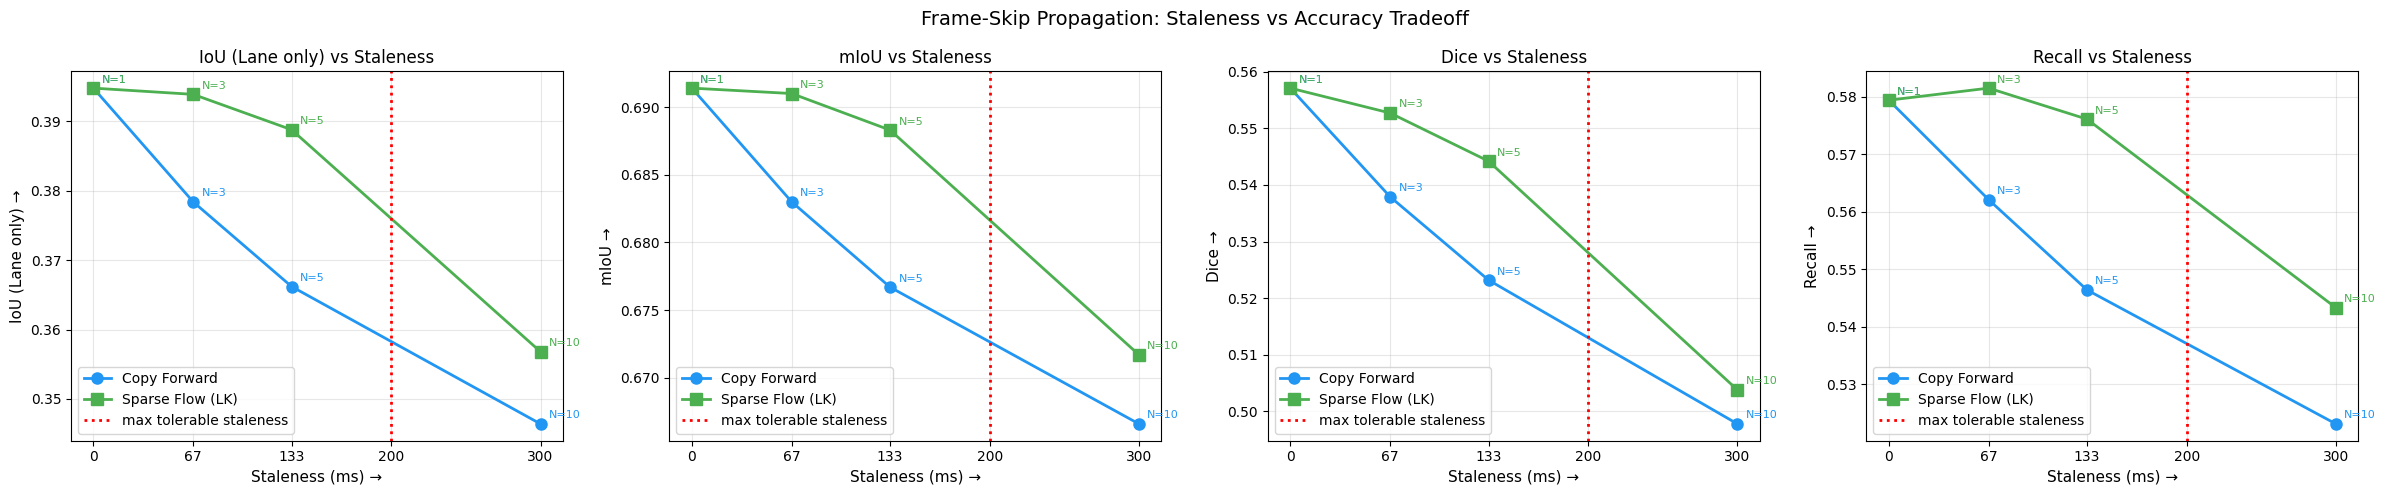

Plot saved.


In [12]:
# ── Cell 8: Plot — FPS vs Accuracy tradeoff ───────────────────────────────────
COLORS  = {"copy_forward": "#2196F3", "sparse_flow": "#4CAF50"}
MARKERS = {"copy_forward": "o",       "sparse_flow": "s"}
LABELS  = {"copy_forward": "Copy Forward", "sparse_flow": "Sparse Flow (LK)"}

# Map skip rate to staleness values: N=1 -> 0ms, N=3 -> 67ms, N=5 -> 133ms, N=10 -> 300ms
STALENESS_MAP = {1: 0, 3: 67, 5: 133, 10: 300}
df_sweep["staleness"] = df_sweep["skip_rate"].map(STALENESS_MAP)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("Frame-Skip Propagation: Staleness vs Accuracy Tradeoff", fontsize=14)

for ax, (col, label) in zip(axes, [("iou_lane", "IoU (Lane only)"),
                                     ("miou",     "mIoU"),
                                     ("dice",     "Dice"),
                                     ("recall",   "Recall")]):
    for mode in MODES:
        sub = df_sweep[df_sweep["mode"] == mode].sort_values("staleness")
        if col not in sub.columns:
            continue
        ax.plot(sub["staleness"], sub[col],
                color=COLORS[mode], marker=MARKERS[mode],
                linewidth=2, markersize=8, label=LABELS[mode])
        for _, r in sub.iterrows():
            ax.annotate(f"N={int(r['skip_rate'])}",
                        (r["staleness"], r[col]),
                        textcoords="offset points", xytext=(6, 4),
                        fontsize=8, color=COLORS[mode])
                        
    # Add vertical dotted red line at x=200 labeled "max tolerable staleness"
    ax.axvline(x=200, color="red", linestyle=":", linewidth=2, label="max tolerable staleness")
    
    ax.set_xlabel("Staleness (ms) →", fontsize=11)
    ax.set_ylabel(f"{label} →", fontsize=11)
    ax.set_title(f"{label} vs Staleness")
    ax.set_xticks([0, 67, 133, 200, 300])  # Tick values updated accordingly
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fps_accuracy_tradeoff.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

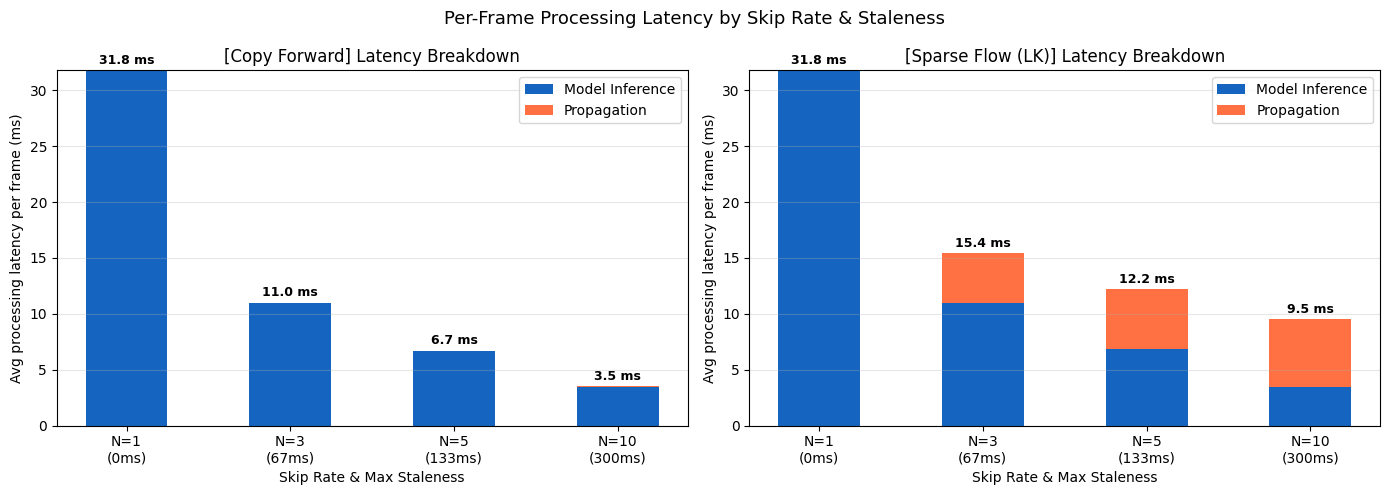

Plot saved.


In [13]:
# ── Cell 9: Plot — Weighted per-frame timing breakdown ───────────────────────
# Uses weighted per-frame averages (not inflated per-event averages)
# so bar height == average processing latency per frame in ms

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("Per-Frame Processing Latency by Skip Rate & Staleness", fontsize=13)

STALENESS_MAP = {1: 0, 3: 67, 5: 133, 10: 300}

for ax2, mode in zip(axes2, MODES):
    sub = df_sweep[df_sweep["mode"] == mode].sort_values("skip_rate")
    x   = np.arange(len(sub))
    w   = 0.5

    model_vals = sub["avg_model_per_frame_ms"].values.astype(float)
    prop_vals  = sub["avg_prop_per_frame_ms"].values.astype(float)

    ax2.bar(x, model_vals, width=w, label="Model Inference", color="#1565C0")
    ax2.bar(x, prop_vals,  width=w, label="Propagation",     color="#FF7043",
            bottom=model_vals)

    ax2.set_xticks(x)
    # Label each skip rate with its maximum staleness
    ax2.set_xticklabels([f"N={int(s)}\n({STALENESS_MAP[int(s)]}ms)" for s in sub["skip_rate"]])
    ax2.set_xlabel("Skip Rate & Max Staleness")
    ax2.set_ylabel("Avg processing latency per frame (ms)")
    ax2.set_title(f"[{LABELS[mode]}] Latency Breakdown")
    ax2.legend()
    ax2.grid(axis="y", alpha=0.3)

    for i, (_, r) in enumerate(sub.iterrows()):
        bar_top = float(r["avg_model_per_frame_ms"]) + float(r["avg_prop_per_frame_ms"])
        # Label the top of each bar with the exact computation latency in ms
        ax2.text(i, bar_top + 0.3, f"{bar_top:.1f} ms",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "timing_breakdown.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

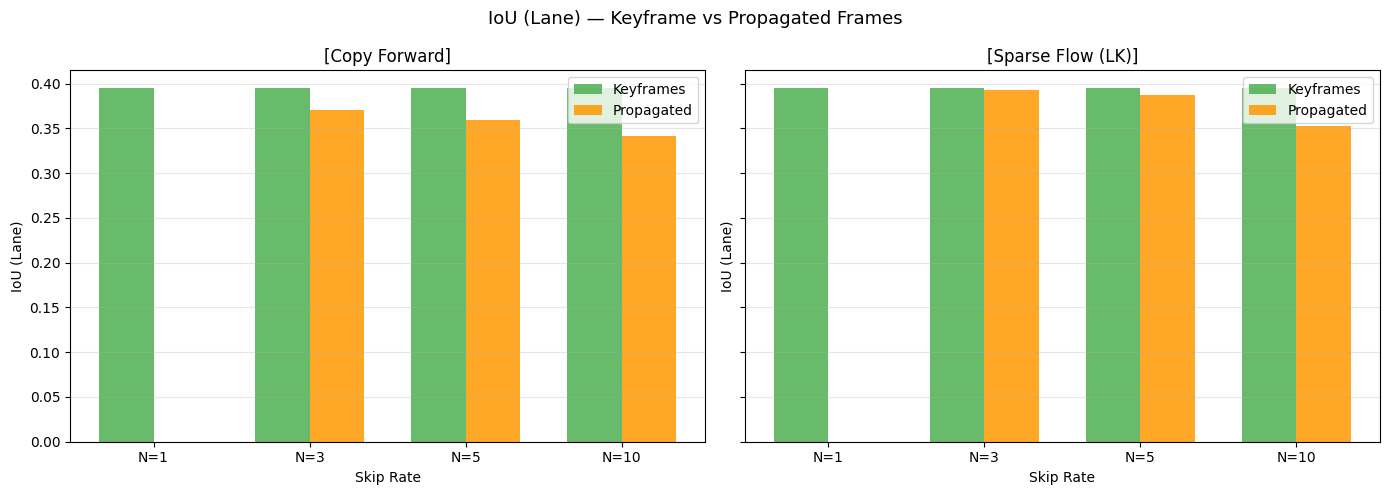

Plot saved.


In [14]:
# ── Cell 10: Plot — Keyframe vs Propagated IoU (Lane) ────────────────────────
if "iou_lane_kf" in df_sweep.columns:
    fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig3.suptitle("IoU (Lane) — Keyframe vs Propagated Frames", fontsize=13)

    for ax3, mode in zip(axes3, MODES):
        sub = (df_sweep[df_sweep["mode"] == mode]
               .sort_values("skip_rate")
               .dropna(subset=["iou_lane_kf"]))
        x = np.arange(len(sub))
        w = 0.35
        ax3.bar(x - w/2, sub["iou_lane_kf"],   width=w,
                label="Keyframes",  color="#4CAF50", alpha=0.85)
        ax3.bar(x + w/2, sub["iou_lane_prop"],  width=w,
                label="Propagated", color="#FF9800", alpha=0.85)
        ax3.set_xticks(x)
        ax3.set_xticklabels([f"N={int(s)}" for s in sub["skip_rate"]])
        ax3.set_xlabel("Skip Rate")
        ax3.set_ylabel("IoU (Lane)")
        ax3.set_title(f"[{LABELS[mode]}]")
        ax3.legend()
        ax3.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, "keyframe_vs_propagated.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved.")
else:
    print("iou_lane_kf column not found — skipping this plot.")


Randomly sampled frames for comparison: [1976, 2130, 2349, 2767, 4037, 6463, 6681, 7091, 7534]
Fetching and reconstructing masks for the 9 random frames on the fly (takes ~2 seconds)...


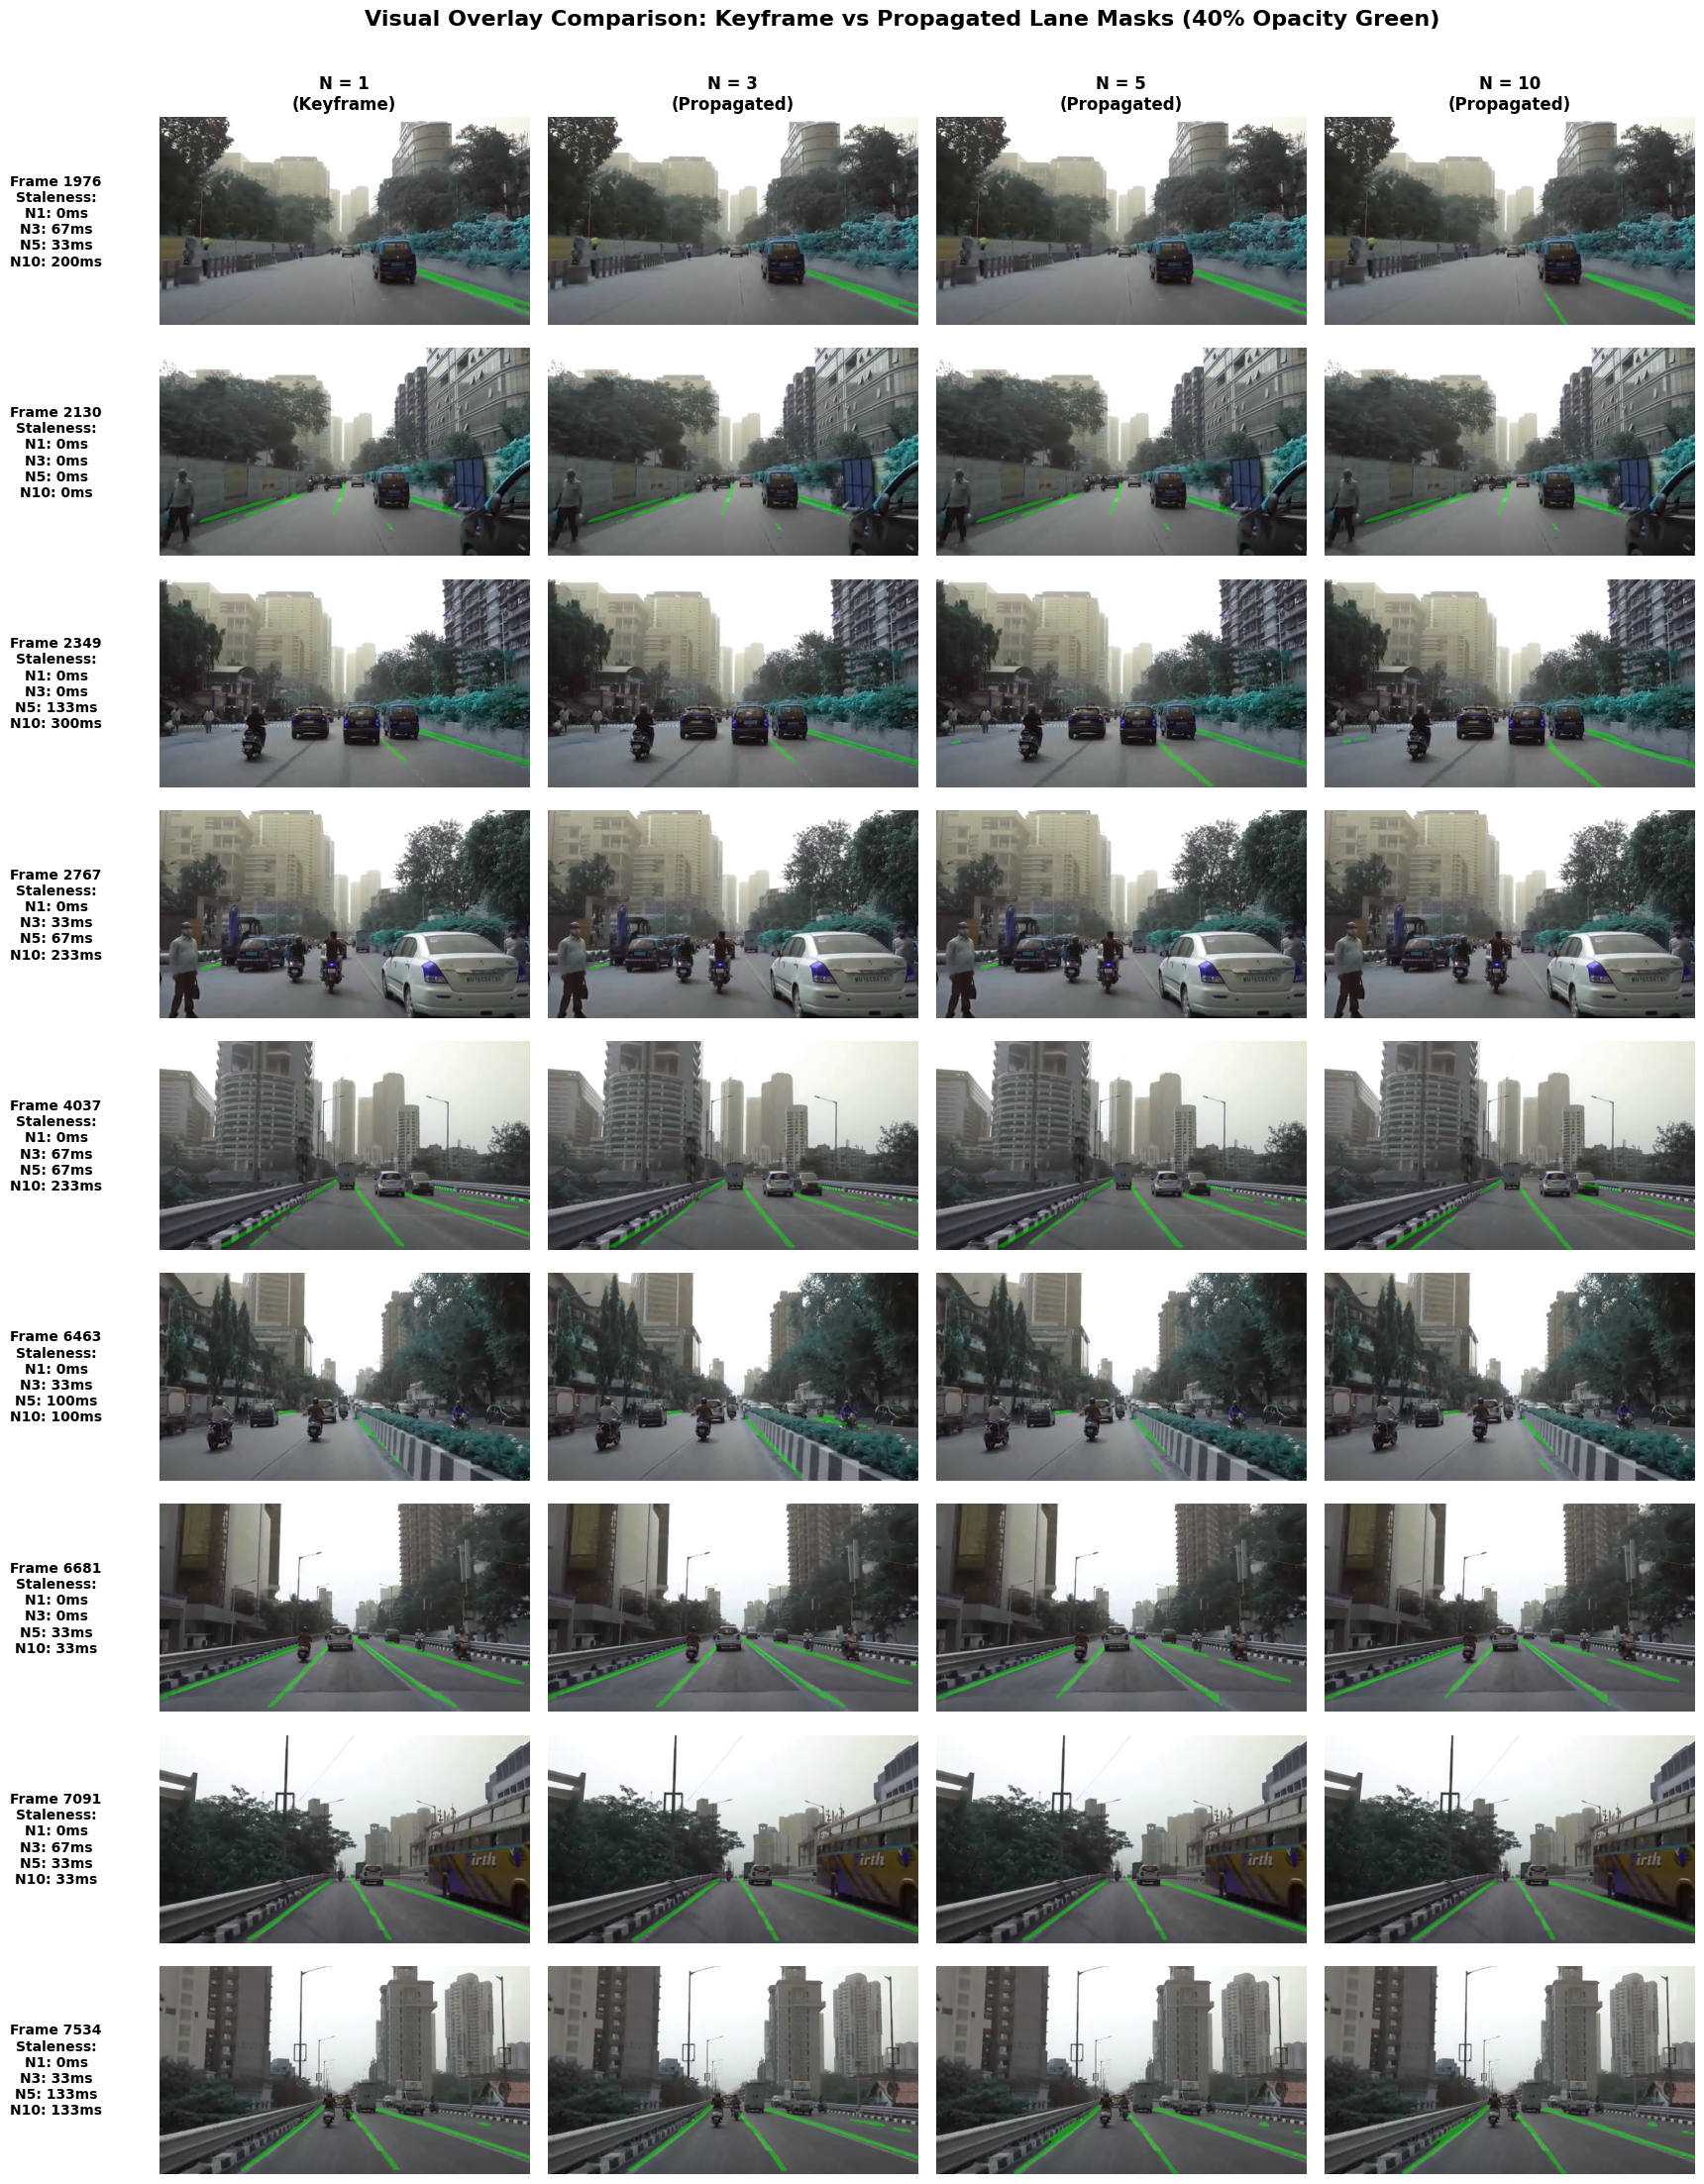

Comparison figure saved as overlay_comparison.png.


In [15]:
# ── Cell 11: Visual Overlay Comparison ──────────────────────────────────────────
import os
import cv2
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F  # Restore F to torch.nn.functional to fix namespace pollution

def get_frame_staleness(frame_idx, N):
    return round((frame_idx % N) * 33.33)

# 1. Determine sample indices (9 unique sorted random frames from the dataset)
sample_indices = sorted(random.sample(range(len(frame_meta)), 9))
print(f"Randomly sampled frames for comparison: {sample_indices}")

# 2. Check if we have pre-cached data in memory; if not, compute it on the fly
# Since indices are random now, we will compute them on the fly to support dynamic runs.
if 'sampled_visualization_data' in globals() and sampled_visualization_data and all(idx in sampled_visualization_data for idx in sample_indices) and all(10 in sampled_visualization_data[idx]["masks"] for idx in sample_indices):
    print("Using pre-cached visualization data from memory...")
    viz_data = sampled_visualization_data
else:
    print("Fetching and reconstructing masks for the 9 random frames on the fly (takes ~2 seconds)...")
    
    # Identify all frame indices we need to read from the loader
    indices_to_read = set()
    for f_idx in sample_indices:
        K3 = f_idx - (f_idx % 3)
        K5 = f_idx - (f_idx % 5)
        K10 = f_idx - (f_idx % 10)
        for idx in range(min(K3, K5, K10), f_idx + 1):
            indices_to_read.add(idx)
            
    # Load only the required frames
    needed_frames = {}
    loader = SilentLoadImages(LOCAL_IMG_DIR, img_size=IMG_SIZE)
    for idx, (path, img, img_det, vid_cap, shapes) in enumerate(loader):
        if idx in indices_to_read:
            needed_frames[idx] = {
                "img": img.copy(),
                "img_det": img_det.copy(),
                "shapes": shapes
            }
        if idx > max(indices_to_read):
            break
            
    # Compute masks
    viz_data = {idx: {"img": needed_frames[idx]["img_det"].copy(), "masks": {}} for idx in sample_indices}
    
    for f_idx in sample_indices:
        # N=1 (keyframe at f_idx)
        data_f = needed_frames[f_idx]
        img_tensor = transform(data_f["img"]).to(device)
        img_tensor = img_tensor.half() if USE_HALF else img_tensor.float()
        if img_tensor.ndimension() == 3:
            img_tensor = img_tensor.unsqueeze(0)
        with torch.no_grad():
            viz_data[f_idx]["masks"][1] = run_model(img_tensor, data_f["img_det"].shape, data_f["shapes"])
            
        # N=3, N=5, N=10 (propagated from their respective nearest keyframe)
        for N in [3, 5, 10]:
            KN = f_idx - (f_idx % N)
            data_KN = needed_frames[KN]
            img_tensor = transform(data_KN["img"]).to(device)
            img_tensor = img_tensor.half() if USE_HALF else img_tensor.float()
            if img_tensor.ndimension() == 3:
                img_tensor = img_tensor.unsqueeze(0)
            with torch.no_grad():
                mask = run_model(img_tensor, data_KN["img_det"].shape, data_KN["shapes"])
                
            prev_mask = mask
            prev_gray = cv2.cvtColor(data_KN["img_det"], cv2.COLOR_BGR2GRAY) if data_KN["img_det"].ndim == 3 else data_KN["img_det"].copy()
            for idx in range(KN + 1, f_idx + 1):
                curr_data = needed_frames[idx]
                curr_gray = cv2.cvtColor(curr_data["img_det"], cv2.COLOR_BGR2GRAY) if curr_data["img_det"].ndim == 3 else curr_data["img_det"].copy()
                prev_mask = propagate_sparse(prev_gray, curr_gray, prev_mask)
                prev_gray = curr_gray
            viz_data[f_idx]["masks"][N] = prev_mask

# 3. Plot the grid comparison
fig, axes = plt.subplots(len(sample_indices), 4, figsize=(20, 3 * len(sample_indices)))
fig.suptitle("Visual Overlay Comparison: Keyframe vs Propagated Lane Masks (40% Opacity Green)", fontsize=16, fontweight="bold", y=0.92)

for r_idx, frame_idx in enumerate(sample_indices):
    data = viz_data[frame_idx]
    img_bgr = data["img"]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    for c_idx, N in enumerate([1, 3, 5, 10]):
        ax = axes[r_idx, c_idx]
        mask = data["masks"].get(N, None)
        
        if mask is not None:
            # Create overlay: draw mask on top of original image in semi-transparent green (40% opacity)
            overlay = img_rgb.copy()
            overlay[mask > 0] = [0, 255, 0]  # Green in RGB
            blended = cv2.addWeighted(overlay, 0.4, img_rgb, 0.6, 0)
            ax.imshow(blended)
        else:
            # Fallback if mask is missing
            ax.imshow(img_rgb)
            ax.text(img_rgb.shape[1]//2, img_rgb.shape[0]//2, f"N={N} mask missing", color="red", ha="center")
            
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
            
        # Label columns clearly on the top row
        if r_idx == 0:
            ax.set_title(f"N = {N}\n(Propagated)" if N > 1 else f"N = {N}\n(Keyframe)", fontsize=12, fontweight="bold")
            
        # Label each row with the frame number and its corresponding staleness values
        if c_idx == 0:
            staleness_str = (
                f"Frame {frame_idx}\n"
                f"Staleness:\n"
                f"N1: {get_frame_staleness(frame_idx, 1)}ms\n"
                f"N3: {get_frame_staleness(frame_idx, 3)}ms\n"
                f"N5: {get_frame_staleness(frame_idx, 5)}ms\n"
                f"N10: {get_frame_staleness(frame_idx, 10)}ms"
            )
            ax.set_ylabel(staleness_str, rotation=0, labelpad=75, verticalalignment="center", fontsize=10, fontweight="bold")

plt.subplots_adjust(wspace=0.05, hspace=0.1)
plt.savefig("overlay_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Comparison figure saved as overlay_comparison.png.")

In [16]:
# ── Step 1: Compute optical flow magnitude for every frame (pre-pass) ─────────
import numpy as np
import cv2
from pathlib import Path

def compute_flow_mag(prev_gray, curr_gray):
    """
    Estimate scene motion using the same sparse LK params as propagate_sparse.
    Returns mean Euclidean displacement across good tracked points,
    or 0.0 if fewer than 6 points are successfully tracked.
    """
    pts = cv2.goodFeaturesToTrack(prev_gray, maxCorners=200,
                                   qualityLevel=0.01, minDistance=10,
                                   blockSize=5)
    if pts is None or len(pts) < 6:
        return 0.0

    curr_pts, status, _ = cv2.calcOpticalFlowPyrLK(
        prev_gray, curr_gray, pts, None,
        winSize=(15, 15), maxLevel=2,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

    good_p = pts[status.ravel() == 1]
    good_c = curr_pts[status.ravel() == 1]
    if len(good_p) < 6:
        return 0.0

    displacements = np.linalg.norm(good_c - good_p, axis=2).ravel()
    return float(displacements.mean())


# ── Pre-pass: iterate all frames, compute flow_mag per consecutive pair ────────
print("Computing flow magnitudes for all frames (pre-pass)...")

flow_mag_per_frame = []
prev_gray_fp       = None
frame_count_fp     = 0

for path, img, img_det, vid_cap, shapes in SilentLoadImages(LOCAL_IMG_DIR, img_size=IMG_SIZE):
    curr_gray_fp = (cv2.cvtColor(img_det, cv2.COLOR_BGR2GRAY)
                    if img_det.ndim == 3 else img_det.copy())

    if prev_gray_fp is None:
        flow_mag_per_frame.append(0.0)   # frame 0: no previous frame
    else:
        flow_mag_per_frame.append(compute_flow_mag(prev_gray_fp, curr_gray_fp))

    prev_gray_fp = curr_gray_fp
    frame_count_fp += 1

print(f"Done. Computed flow_mag for {frame_count_fp} frames.")

# ── Percentile distribution (excluding frame 0) ───────────────────────────────
mags_excl0 = np.array(flow_mag_per_frame[1:])
print("\nFlow magnitude percentiles (px, excluding frame 0):")
for p in [10, 25, 50, 75, 90]:
    print(f"  p{p:2d}: {np.percentile(mags_excl0, p):.4f} px")

Computing flow magnitudes for all frames (pre-pass)...
Done. Computed flow_mag for 8639 frames.

Flow magnitude percentiles (px, excluding frame 0):
  p10: 1.3938 px
  p25: 2.0076 px
  p50: 2.7493 px
  p75: 3.6623 px
  p90: 4.5344 px


Speed bin frame counts:
  low     :  2144 frames  (24.8%)
  medium  :  5922 frames  (68.5%)
  high    :   573 frames  (6.6%)


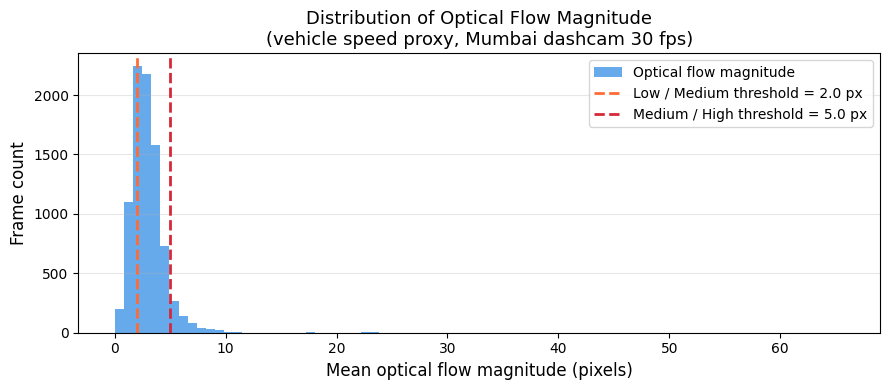

Saved: /content/drive/MyDrive/India's New York City - Mumbai 4K - Driving Downtown_30fps/results_yolopx/flow_mag_histogram.png


In [17]:
# ── Step 2: Assign speed bins & plot flow magnitude histogram ────────────────
import os
import matplotlib.pyplot as plt
from collections import Counter

LOW_THRESH  = 2.0   # px  (low / medium boundary)
HIGH_THRESH = 5.0   # px  (medium / high boundary)

def assign_speed_bin(mag):
    if mag < LOW_THRESH:
        return "low"
    elif mag < HIGH_THRESH:
        return "medium"
    else:
        return "high"

speed_bin_per_frame = [assign_speed_bin(m) for m in flow_mag_per_frame]

# ── Print frame counts per bin ───────────────────────────────────────────
bin_counts = Counter(speed_bin_per_frame)
total_f = len(speed_bin_per_frame)
print("Speed bin frame counts:")
for b in ["low", "medium", "high"]:
    print(f"  {b:8s}: {bin_counts[b]:5d} frames  ({100 * bin_counts[b] / total_f:.1f}%)")

# ── Histogram of flow magnitudes ─────────────────────────────────────────
mags_excl0 = np.array(flow_mag_per_frame[1:])

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(mags_excl0, bins=80, color="#4C9BE8", edgecolor="none", alpha=0.85,
        label="Optical flow magnitude")
ax.axvline(LOW_THRESH,  color="#FF6B35", linestyle="--", linewidth=2.0,
           label=f"Low / Medium threshold = {LOW_THRESH} px")
ax.axvline(HIGH_THRESH, color="#D62839", linestyle="--", linewidth=2.0,
           label=f"Medium / High threshold = {HIGH_THRESH} px")
ax.set_xlabel("Mean optical flow magnitude (pixels)", fontsize=12)
ax.set_ylabel("Frame count", fontsize=12)
ax.set_title(
    "Distribution of Optical Flow Magnitude\n"
    "(vehicle speed proxy, Mumbai dashcam 30 fps)",
    fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()

hist_path = os.path.join(RESULTDIR, "flow_mag_histogram.png")
plt.savefig(hist_path, dpi=150)
plt.show()
print(f"Saved: {hist_path}")

In [18]:
# ── Step 3: Speed-conditioned sweep (sparse_flow only, all 4 skip rates) ───────
import time
import torch
import pandas as pd
from pathlib import Path
from tqdm import tqdm

print("Running speed-conditioned sweep (sparse_flow, all skip rates)...")
speed_sweep_rows = []

for skip_rate in SKIP_RATES:
    print(f"\n▶  skip_rate={skip_rate}  mode=sparse_flow")

    prev_gray_sw = None
    prev_mask_sw = None
    frame_idx_sw = 0

    for path, img, img_det, vid_cap, shapes in tqdm(
            SilentLoadImages(LOCAL_IMG_DIR, img_size=IMG_SIZE),
            total=len(frame_meta), leave=False):

        base_name    = Path(path).name
        img_tensor   = transform(img).to(device)
        img_tensor   = img_tensor.half() if USE_HALF else img_tensor.float()
        if img_tensor.ndimension() == 3:
            img_tensor = img_tensor.unsqueeze(0)

        curr_gray_sw = (cv2.cvtColor(img_det, cv2.COLOR_BGR2GRAY)
                        if img_det.ndim == 3 else img_det.copy())

        is_keyframe = (frame_idx_sw % skip_rate == 0) or (prev_mask_sw is None)

        if is_keyframe:
            with torch.no_grad():
                pred_mask = run_model(img_tensor, img_det.shape, shapes)
            if device.type == "cuda":
                torch.cuda.synchronize()
        else:
            pred_mask = propagate_sparse(prev_gray_sw, curr_gray_sw, prev_mask_sw)

        # Evaluate against GT and tag with speed bin
        if base_name in gt_cache:
            pred_d = dilate_mask(pred_mask, DILATION_K)
            m = compute_metrics(gt_cache[base_name], pred_d)
            sbin = (speed_bin_per_frame[frame_idx_sw]
                    if frame_idx_sw < len(speed_bin_per_frame) else "low")
            speed_sweep_rows.append({
                "skip_rate": skip_rate,
                "speed_bin": sbin,
                "iou_lane":  m["iou_lane"],
                "frame_idx": frame_idx_sw,
            })

        prev_gray_sw = curr_gray_sw
        prev_mask_sw = pred_mask
        frame_idx_sw += 1

    print(f"   → {frame_idx_sw} frames processed")

# ── Aggregate into df_speed ─────────────────────────────────────────────────
df_speed_raw = pd.DataFrame(speed_sweep_rows)
df_speed = (
    df_speed_raw
    .groupby(["skip_rate", "speed_bin"])
    .agg(iou_lane=("iou_lane", "mean"), n_frames=("iou_lane", "count"))
    .reset_index()
)
df_speed["iou_lane"] = df_speed["iou_lane"].round(4)
df_speed = df_speed.sort_values(["speed_bin", "skip_rate"]).reset_index(drop=True)

print("\n\n═══ SPEED-CONDITIONED IoU TABLE ═══")
print(df_speed.to_string(index=False))

csv_path = os.path.join(RESULTDIR, "speed_conditioned_iou.csv")
df_speed.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")

Running speed-conditioned sweep (sparse_flow, all skip rates)...

▶  skip_rate=1  mode=sparse_flow


   → 8639 frames processed

▶  skip_rate=3  mode=sparse_flow


   → 8639 frames processed

▶  skip_rate=5  mode=sparse_flow


   → 8639 frames processed

▶  skip_rate=10  mode=sparse_flow


   → 8639 frames processed


═══ SPEED-CONDITIONED IoU TABLE ═══
 skip_rate speed_bin  iou_lane  n_frames
         1      high    0.4100       573
         3      high    0.4153       573
         5      high    0.4045       573
        10      high    0.3631       573
         1       low    0.3545      2144
         3       low    0.3327      2144
         5       low    0.3186      2144
        10       low    0.2792      2144
         1    medium    0.4079      5922
         3    medium    0.4140      5922
         5    medium    0.4127      5922
        10    medium    0.3843      5922

Saved: /content/drive/MyDrive/India's New York City - Mumbai 4K - Driving Downtown_30fps/results_yolopx/speed_conditioned_iou.csv


N=1 overall IoU baseline : 0.3948
10% degradation floor    : 0.3553


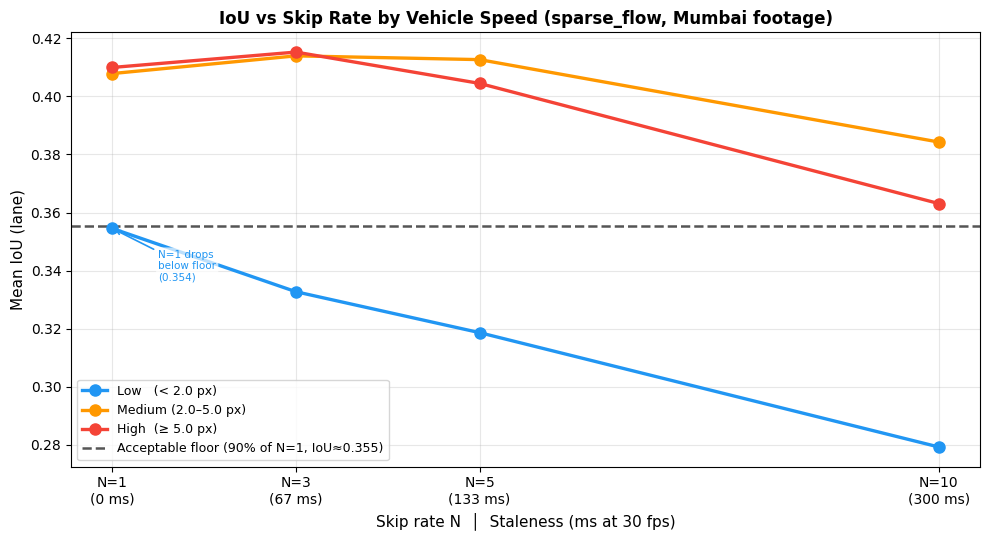

Saved: /content/drive/MyDrive/India's New York City - Mumbai 4K - Driving Downtown_30fps/results_yolopx/speed_iou_tradeoff.png


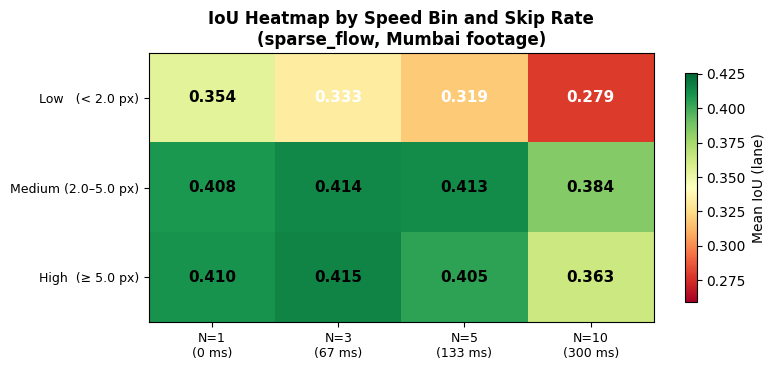

Saved: /content/drive/MyDrive/India's New York City - Mumbai 4K - Driving Downtown_30fps/results_yolopx/speed_iou_heatmap.png


In [19]:
# ── Step 4: Speed-conditioned plots ───────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

FPS          = 30.0
STALENESS_MS = {n: round((n - 1) / FPS * 1000) for n in SKIP_RATES}  # ms of staleness

BIN_COLORS = {"low": "#2196F3", "medium": "#FF9800", "high": "#F44336"}
BIN_LABELS = {
    "low":    f"Low   (< {LOW_THRESH} px)",
    "medium": f"Medium ({LOW_THRESH}–{HIGH_THRESH} px)",
    "high":   f"High  (≥ {HIGH_THRESH} px)",
}

# ── N=1 overall baseline from df_speed (sparse_flow @ N=1, mean across speed bins) ──
n1_rows = df_speed[df_speed["skip_rate"] == 1]
if not n1_rows.empty:
    # Weighted average by n_frames
    iou_lane_N1_overall = (
        (n1_rows["iou_lane"] * n1_rows["n_frames"]).sum() / n1_rows["n_frames"].sum()
    )
else:
    # Fall back to df_sweep N=1 sparse_flow
    iou_lane_N1_overall = df_sweep.loc[
        (df_sweep["skip_rate"] == 1) & (df_sweep["mode"] == "sparse_flow"),
        "iou_lane"
    ].values[0]

quality_floor = 0.9 * iou_lane_N1_overall
print(f"N=1 overall IoU baseline : {iou_lane_N1_overall:.4f}")
print(f"10% degradation floor    : {quality_floor:.4f}")

# ──────────────────────────────────────────────────────────────────────────────
# Plot 1: Line chart — IoU vs Skip Rate, one line per speed bin
# ──────────────────────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 5.5))

for sbin in ["low", "medium", "high"]:
    sub = df_speed[df_speed["speed_bin"] == sbin].sort_values("skip_rate")
    if sub.empty:
        continue
    x = sub["skip_rate"].values
    y = sub["iou_lane"].values
    ax1.plot(x, y, color=BIN_COLORS[sbin], marker="o", linewidth=2.4,
             markersize=8, label=BIN_LABELS[sbin], zorder=3)

    # Annotate first point where IoU drops below quality_floor
    below = np.where(y < quality_floor)[0]
    if len(below) > 0:
        xi, yi = x[below[0]], y[below[0]]
        ax1.annotate(
            f"N={xi} drops\nbelow floor\n({yi:.3f})",
            xy=(xi, yi),
            xytext=(xi + 0.5, yi - 0.018),
            fontsize=7.5, color=BIN_COLORS[sbin],
            arrowprops=dict(arrowstyle="->", color=BIN_COLORS[sbin], lw=1.2),
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, lw=0),
        )

# Acceptable quality floor
ax1.axhline(quality_floor, color="#555555", linestyle="--", linewidth=1.8, zorder=2,
            label=f"Acceptable floor (90% of N=1, IoU≈{quality_floor:.3f})")

ax1.set_xticks(SKIP_RATES)
ax1.set_xticklabels([f"N={n}\n({STALENESS_MS[n]} ms)" for n in SKIP_RATES], fontsize=10)
ax1.set_xlabel("Skip rate N  │  Staleness (ms at 30 fps)", fontsize=11)
ax1.set_ylabel("Mean IoU (lane)", fontsize=11)
ax1.set_title(
    "IoU vs Skip Rate by Vehicle Speed (sparse_flow, Mumbai footage)",
    fontsize=12, fontweight="bold"
)
ax1.legend(fontsize=9, loc="lower left")
ax1.grid(alpha=0.3)
plt.tight_layout()

p1_path = os.path.join(RESULTDIR, "speed_iou_tradeoff.png")
plt.savefig(p1_path, dpi=150)
plt.show()
print(f"Saved: {p1_path}")

# ──────────────────────────────────────────────────────────────────────────────
# Plot 2: Heatmap — rows=speed_bin, cols=skip_rate
# ──────────────────────────────────────────────────────────────────────────────
BINS_ORDER  = ["low", "medium", "high"]
heatmap_data = np.full((len(BINS_ORDER), len(SKIP_RATES)), np.nan)

for i, sbin in enumerate(BINS_ORDER):
    for j, sr in enumerate(SKIP_RATES):
        row = df_speed[(df_speed["speed_bin"] == sbin) & (df_speed["skip_rate"] == sr)]
        if not row.empty:
            heatmap_data[i, j] = row["iou_lane"].values[0]

vmin = max(0.0, float(np.nanmin(heatmap_data)) - 0.02)
vmax = float(np.nanmax(heatmap_data)) + 0.01
mid  = (vmin + vmax) / 2

fig2, ax2 = plt.subplots(figsize=(8, 3.8))
im = ax2.imshow(heatmap_data, cmap="RdYlGn", vmin=vmin, vmax=vmax, aspect="auto")

ax2.set_xticks(range(len(SKIP_RATES)))
ax2.set_xticklabels([f"N={n}\n({STALENESS_MS[n]} ms)" for n in SKIP_RATES], fontsize=9)
ax2.set_yticks(range(len(BINS_ORDER)))
ax2.set_yticklabels([BIN_LABELS[b] for b in BINS_ORDER], fontsize=9)
ax2.set_title(
    "IoU Heatmap by Speed Bin and Skip Rate\n(sparse_flow, Mumbai footage)",
    fontsize=12, fontweight="bold"
)

# Annotate each cell with its IoU value; use white text on dark cells
for i in range(len(BINS_ORDER)):
    for j in range(len(SKIP_RATES)):
        val = heatmap_data[i, j]
        if not np.isnan(val):
            text_color = "white" if val < mid else "black"
            ax2.text(j, i, f"{val:.3f}", ha="center", va="center",
                     fontsize=11, fontweight="bold", color=text_color)

plt.colorbar(im, ax=ax2, label="Mean IoU (lane)", shrink=0.85)
plt.tight_layout()

p2_path = os.path.join(RESULTDIR, "speed_iou_heatmap.png")
plt.savefig(p2_path, dpi=150)
plt.show()
print(f"Saved: {p2_path}")

In [20]:
# ── Step 5: Safe skip-rate recommendations ────────────────────────────────────
FPS             = 30.0
THRESHOLD_FRAC  = 0.10   # >10% relative IoU drop = "unsafe"

# Labels for printing
BIN_PRINT_LABEL = {
    "low":    f"Low speed    (flow < {LOW_THRESH} px)",
    "medium": f"Medium speed ({LOW_THRESH}–{HIGH_THRESH} px) ",
    "high":   f"High speed   (flow >= {HIGH_THRESH} px) ",
}

print("=" * 65)
print("=== Safe Skip Rate Recommendations                           ===")
print("===   (sparse_flow, >10% IoU drop threshold)                 ===")
print("=" * 65)

for sbin in ["low", "medium", "high"]:
    sub = df_speed[df_speed["speed_bin"] == sbin].sort_values("skip_rate")
    if sub.empty:
        print(f"  {BIN_PRINT_LABEL[sbin]}: No data")
        continue

    # Per-bin N=1 baseline; fall back to overall if missing
    n1_row = sub[sub["skip_rate"] == 1]
    if not n1_row.empty:
        iou_base = n1_row["iou_lane"].values[0]
    else:
        iou_base = iou_lane_N1_overall

    floor_bin = iou_base * (1 - THRESHOLD_FRAC)

    # Walk through ascending skip rates; keep the last one that stays above floor
    safe_n = int(sub["skip_rate"].iloc[0])  # at minimum N=1 is safe
    for _, row_s in sub.iterrows():
        if row_s["iou_lane"] >= floor_bin:
            safe_n = int(row_s["skip_rate"])
        else:
            break  # first failure — stop (skip rates are sorted ascending)

    staleness_ms = round((safe_n - 1) / FPS * 1000)
    print(f"  {BIN_PRINT_LABEL[sbin]:40s}:  "
          f"Safe up to N={safe_n}  (staleness={staleness_ms} ms)")

print()
print(f"  Baseline: N=1 overall IoU      = {iou_lane_N1_overall:.4f}")
print(f"  Quality floor (90% of N=1)     = {0.9 * iou_lane_N1_overall:.4f}")
print(f"  Frame duration at 30 fps       = {1000/FPS:.2f} ms")
print("=" * 65)

=== Safe Skip Rate Recommendations                           ===
===   (sparse_flow, >10% IoU drop threshold)                 ===
  Low speed    (flow < 2.0 px)            :  Safe up to N=3  (staleness=67 ms)
  Medium speed (2.0–5.0 px)               :  Safe up to N=10  (staleness=300 ms)
  High speed   (flow >= 5.0 px)           :  Safe up to N=5  (staleness=133 ms)

  Baseline: N=1 overall IoU      = 0.3948
  Quality floor (90% of N=1)     = 0.3553
  Frame duration at 30 fps       = 33.33 ms


═════════════════════════════════════════════════════════════════
Relative IoU Degradation vs N=1 baseline (per frame, %)
═════════════════════════════════════════════════════════════════
 skip_rate speed_bin  mean_rel_drop_pct  median_rel_drop_pct  n_frames
         3      high              -1.31                 0.00       568
         5      high               0.97                 0.00       568
        10      high              10.53                 3.57       568
         3       low               6.39                 0.00      1906
         5       low              10.66                 3.83      1906
        10       low              21.66                16.84      1906
         3    medium              -1.41                 0.00      5886
         5    medium              -1.02                 0.00      5886
        10    medium               5.92                 0.00      5886

Interpretation: a value of 10.0 means the propagated mask
                lost 10% of its IoU relativ

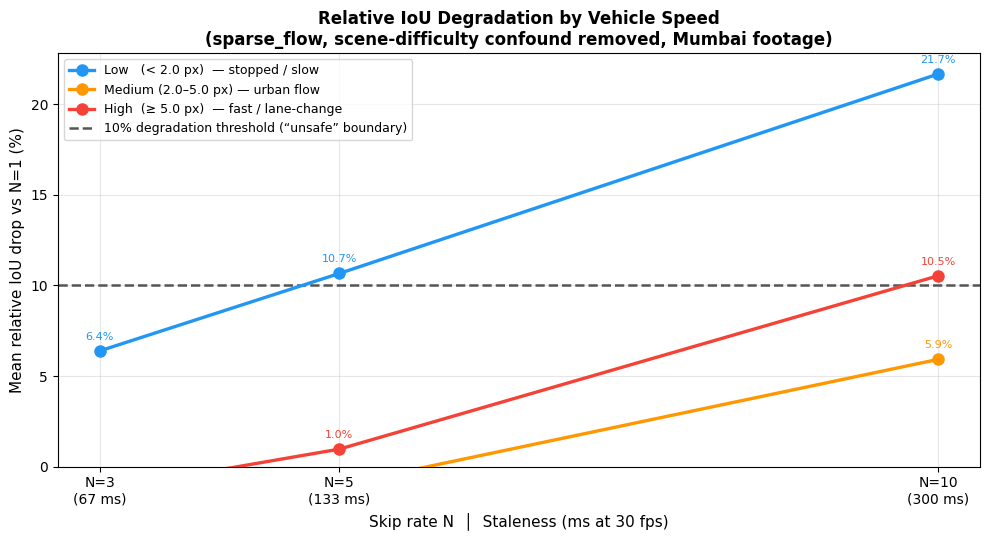

Saved: /content/drive/MyDrive/India's New York City - Mumbai 4K - Driving Downtown_30fps/results_yolopx/speed_relative_iou_drop.png

═════════════════════════════════════════════════════════════════
=== Corrected Safe Skip Rate Recommendations               ===
===   (relative degradation, confound-free)                ===
═════════════════════════════════════════════════════════════════
  Low speed    (flow < 2.0 px)          : Safe up to N=3  (staleness=67 ms)
  Medium speed (2.0–5.0 px)             : Safe up to N=10  (staleness=300 ms)
  High speed   (flow ≥ 5.0 px)          : Safe up to N=5  (staleness=133 ms)
═════════════════════════════════════════════════════════════════


In [23]:
# ── Cell 18: Relative IoU Degradation by Speed Bin (corrected analysis) ────────
#
# Fix for the scene-difficulty confound:
# Instead of comparing absolute IoU across speed bins (which mixes scene
# difficulty with staleness), we compute for each frame:
#
#   relative_drop(N) = (iou_at_N1 - iou_at_N) / iou_at_N1
#
# This cancels out the per-frame baseline difficulty and isolates the
# pure staleness penalty. A value of 0.10 means the mask degraded 10%
# relative to a fresh keyframe on that same frame.
#
# Crucially, we exclude frames where the N=1 baseline IoU is <= 0.10
# to prevent division-by-near-zero artifacts blowing up the mean.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ── Build per-frame N=1 baseline ──────────────────────────────────────────
df_raw     = pd.DataFrame(speed_sweep_rows)   # already in memory from Step 3
df_n1      = df_raw[df_raw["skip_rate"] == 1][["frame_idx", "iou_lane"]].rename(
                 columns={"iou_lane": "iou_n1"})

# Merge N=1 baseline onto every row
df_rel = df_raw.merge(df_n1, on="frame_idx", how="inner")

# Filter out frames where keyframe has extremely low or zero IoU (no lane detected or no GT lane)
# to avoid division by zero/near-zero blowing up the relative drop.
df_rel = df_rel[df_rel["iou_n1"] > 0.10].copy()

# Relative drop: positive = degradation, negative = (rare) improvement
df_rel["rel_drop"] = (df_rel["iou_n1"] - df_rel["iou_lane"]) / df_rel["iou_n1"]

# Only look at N > 1 (N=1 vs itself is trivially 0)
df_rel_skipped = df_rel[df_rel["skip_rate"] > 1].copy()

# ── Aggregate: mean relative drop per (skip_rate, speed_bin) ────────────────
df_rel_agg = (
    df_rel_skipped
    .groupby(["skip_rate", "speed_bin"])
    .agg(
        mean_rel_drop=("rel_drop", "mean"),
        median_rel_drop=("rel_drop", "median"),
        n_frames=("rel_drop", "count"),
    )
    .reset_index()
)
df_rel_agg["mean_rel_drop_pct"]   = (df_rel_agg["mean_rel_drop"]   * 100).round(2)
df_rel_agg["median_rel_drop_pct"] = (df_rel_agg["median_rel_drop"] * 100).round(2)
df_rel_agg = df_rel_agg.sort_values(["speed_bin", "skip_rate"]).reset_index(drop=True)

print("═" * 65)
print("Relative IoU Degradation vs N=1 baseline (per frame, %)")
print("═" * 65)
print(df_rel_agg[["skip_rate","speed_bin","mean_rel_drop_pct",
                   "median_rel_drop_pct","n_frames"]].to_string(index=False))
print()
print("Interpretation: a value of 10.0 means the propagated mask")
print("                lost 10% of its IoU relative to a fresh keyframe")
print("                on that exact same frame.")

# Save CSV
csv2_path = os.path.join(RESULTDIR, "speed_relative_iou_drop.csv")
df_rel_agg.to_csv(csv2_path, index=False)
print(f"\nSaved: {csv2_path}")

# ── Plot: mean relative drop % vs skip rate, one line per speed bin ────────
SKIP_RATES_PLOT = sorted(df_rel_skipped["skip_rate"].unique())
STALENESS_MS    = {n: round((n - 1) / 30.0 * 1000) for n in SKIP_RATES}
BIN_COLORS      = {"low": "#2196F3", "medium": "#FF9800", "high": "#F44336"}
BIN_LABELS      = {
    "low":    f"Low   (< {LOW_THRESH} px)  — stopped / slow",
    "medium": f"Medium ({LOW_THRESH}–{HIGH_THRESH} px) — urban flow",
    "high":   f"High  (≥ {HIGH_THRESH} px)  — fast / lane-change",
}

fig, ax = plt.subplots(figsize=(10, 5.5))

for sbin in ["low", "medium", "high"]:
    sub = df_rel_agg[df_rel_agg["speed_bin"] == sbin].sort_values("skip_rate")
    if sub.empty:
        continue
    ax.plot(sub["skip_rate"], sub["mean_rel_drop_pct"],
            color=BIN_COLORS[sbin], marker="o", linewidth=2.4,
            markersize=8, label=BIN_LABELS[sbin], zorder=3)
    # Annotate each point with its value
    for _, r in sub.iterrows():
        ax.annotate(f"{r['mean_rel_drop_pct']:.1f}%",
                    xy=(r["skip_rate"], r["mean_rel_drop_pct"]),
                    xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=8, color=BIN_COLORS[sbin])

# 10% threshold line
ax.axhline(10.0, color="#555555", linestyle="--", linewidth=1.8, zorder=2,
           label="10% degradation threshold (\u201cunsafe\u201d boundary)")

ax.set_xticks(SKIP_RATES_PLOT)
ax.set_xticklabels([f"N={n}\n({STALENESS_MS[n]} ms)" for n in SKIP_RATES_PLOT], fontsize=10)
ax.set_xlabel("Skip rate N  │  Staleness (ms at 30 fps)", fontsize=11)
ax.set_ylabel("Mean relative IoU drop vs N=1 (%)", fontsize=11)
ax.set_title(
    "Relative IoU Degradation by Vehicle Speed\n"
    "(sparse_flow, scene-difficulty confound removed, Mumbai footage)",
    fontsize=12, fontweight="bold"
)
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()

rel_path = os.path.join(RESULTDIR, "speed_relative_iou_drop.png")
plt.savefig(rel_path, dpi=150)
plt.show()
print(f"Saved: {rel_path}")

# ── Corrected text recommendations ───────────────────────────────────────────
print()
print("═" * 65)
print("=== Corrected Safe Skip Rate Recommendations               ===")
print("===   (relative degradation, confound-free)                ===")
print("═" * 65)

BIN_PRINT_LABEL2 = {
    "low":    f"Low speed    (flow < {LOW_THRESH} px) ",
    "medium": f"Medium speed ({LOW_THRESH}–{HIGH_THRESH} px)",
    "high":   f"High speed   (flow ≥ {HIGH_THRESH} px) ",
}

for sbin in ["low", "medium", "high"]:
    sub = df_rel_agg[df_rel_agg["speed_bin"] == sbin].sort_values("skip_rate")
    if sub.empty:
        print(f"  {BIN_PRINT_LABEL2[sbin]}: No data")
        continue
    # Highest N where mean drop stays below 10%
    safe_n = 1  # N=1 is always safe (0% drop by definition)
    for _, r in sub.iterrows():
        if r["mean_rel_drop_pct"] < 10.0:
            safe_n = int(r["skip_rate"])
        else:
            break
    staleness = round((safe_n - 1) / 30.0 * 1000)
    print(f"  {BIN_PRINT_LABEL2[sbin]:38s}: Safe up to N={safe_n}  "
          f"(staleness={staleness} ms)")
print("═" * 65)

In [ ]:
# ── Cell 19: Test Option 1 — Adaptive Flow (Fallback to Copy-Forward at Low Speeds) ──
import time
import torch
import pandas as pd
from pathlib import Path
from tqdm import tqdm

def propagate_adaptive(prev_gray, curr_gray, prev_mask, flow_mag):
    """
    If the scene movement is low (flow_mag < 2.0 px), avoid warping and copy forward.
    Otherwise, run Lucas-Kanade sparse flow propagation.
    """
    if flow_mag < 2.0:
        return prev_mask.copy()
    return propagate_sparse(prev_gray, curr_gray, prev_mask)


# ── Run the Adaptive Flow sweep ───────────────────────────────────────────────
print("Running adaptive flow sweep (all skip rates)...")
adaptive_sweep_rows = []

for skip_rate in SKIP_RATES:
    print(f"\n▶  skip_rate={skip_rate}  mode=adaptive_flow")

    prev_gray_ad = None
    prev_mask_ad = None
    frame_idx_ad = 0

    for path, img, img_det, vid_cap, shapes in tqdm(
            SilentLoadImages(LOCAL_IMG_DIR, img_size=IMG_SIZE),
            total=len(frame_meta), leave=False):

        base_name    = Path(path).name
        img_tensor   = transform(img).to(device)
        img_tensor   = img_tensor.half() if USE_HALF else img_tensor.float()
        if img_tensor.ndimension() == 3:
            img_tensor = img_tensor.unsqueeze(0)

        curr_gray_ad = (cv2.cvtColor(img_det, cv2.COLOR_BGR2GRAY)
                        if img_det.ndim == 3 else img_det.copy())

        is_keyframe = (frame_idx_ad % skip_rate == 0) or (prev_mask_ad is None)

        if is_keyframe:
            with torch.no_grad():
                pred_mask = run_model(img_tensor, img_det.shape, shapes)
            if device.type == "cuda":
                torch.cuda.synchronize()
        else:
            # Look up flow_mag for the current frame to decide propagation strategy
            fmag = flow_mag_per_frame[frame_idx_ad]
            pred_mask = propagate_adaptive(prev_gray_ad, curr_gray_ad, prev_mask_ad, fmag)

        # Evaluate against GT and tag with speed bin
        if base_name in gt_cache:
            pred_d = dilate_mask(pred_mask, DILATION_K)
            m = compute_metrics(gt_cache[base_name], pred_d)
            sbin = (speed_bin_per_frame[frame_idx_ad]
                    if frame_idx_ad < len(speed_bin_per_frame) else "low")
            adaptive_sweep_rows.append({
                "skip_rate": skip_rate,
                "speed_bin": sbin,
                "iou_lane":  m["iou_lane"],
                "frame_idx": frame_idx_ad,
            })

        prev_gray_ad = curr_gray_ad
        prev_mask_ad = pred_mask
        frame_idx_ad += 1

# ── Process results and compute relative drop ─────────────────────────────────
df_ad_raw = pd.DataFrame(adaptive_sweep_rows)
df_ad_n1  = df_ad_raw[df_ad_raw["skip_rate"] == 1][["frame_idx", "iou_lane"]].rename(
                columns={"iou_lane": "iou_n1"})

df_ad_rel = df_ad_raw.merge(df_ad_n1, on="frame_idx", how="inner")
df_ad_rel = df_ad_rel[df_ad_rel["iou_n1"] > 0.10].copy()
df_ad_rel["rel_drop"] = (df_ad_rel["iou_n1"] - df_ad_rel["iou_lane"]) / df_ad_rel["iou_n1"]

df_ad_agg = (
    df_ad_rel[df_ad_rel["skip_rate"] > 1]
    .groupby(["skip_rate", "speed_bin"])
    .agg(mean_rel_drop=("rel_drop", "mean"))
    .reset_index()
)
df_ad_agg["mean_rel_drop_pct"] = (df_ad_agg["mean_rel_drop"] * 100).round(2)

# ── Compare side-by-side with pure sparse flow ────────────────────────────────
# From pure sparse flow: df_rel_agg (assumes it is in memory from Cell 18)
df_compare = df_rel_agg[["skip_rate", "speed_bin", "mean_rel_drop_pct"]].rename(
    columns={"mean_rel_drop_pct": "pure_sparse_flow_drop_%"}
)
df_compare = df_compare.merge(
    df_ad_agg[["skip_rate", "speed_bin", "mean_rel_drop_pct"]].rename(
        columns={"mean_rel_drop_pct": "adaptive_flow_drop_%"}
    ),
    on=["skip_rate", "speed_bin"],
    how="left"
)

print("\n" + "═"*75)
print(" COMPARISON: Pure Sparse Flow vs. Option 1 Adaptive Flow")
print(" (Mean Relative IoU Degradation %, lower is better)")
print("═"*75)
print(df_compare.to_string(index=False))
print("═"*75)

Running adaptive flow sweep (all skip rates)...

▶  skip_rate=1  mode=adaptive_flow



▶  skip_rate=3  mode=adaptive_flow



▶  skip_rate=5  mode=adaptive_flow


 90%|█████████ | 7776/8639 [02:15<00:18, 46.03it/s]